# Imports

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import seaborn as sns
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/fashionmnist/fashion-mnist_test.csv
/kaggle/input/fashionmnist/fashion-mnist_train.csv
/kaggle/input/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/fashionmnist/train-images-idx3-ubyte


#  Fashion MNIST

Load Data

In [2]:
mnist_train = pd.read_csv('/kaggle/input/fashionmnist/fashion-mnist_train.csv')
mnist_test = pd.read_csv('/kaggle/input/fashionmnist/fashion-mnist_test.csv')


In [3]:
mnist_train.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
labels = {0 : "T-shirt/top", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat",
          5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle Boot"}

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


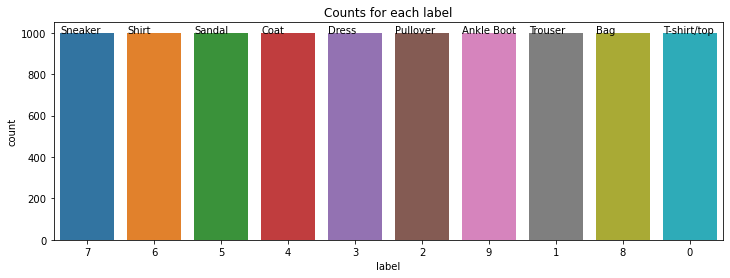

In [5]:

import matplotlib.pyplot as plt
def plot_label_per_class(data):
    f, ax = plt.subplots(1,1, figsize=(12,4))
    g = sns.countplot(data.label, order = data["label"].value_counts().index)
    g.set_title("Counts for each label")

    for p, label in zip(g.patches, data["label"].value_counts().index):
        g.annotate(labels[label], (p.get_x(), p.get_height()+0.1))
    plt.show()  
    
plot_label_per_class(mnist_test)


In [6]:
mnist_train.isnull().any().sum(), mnist_test.isnull().any().sum()



(0, 0)

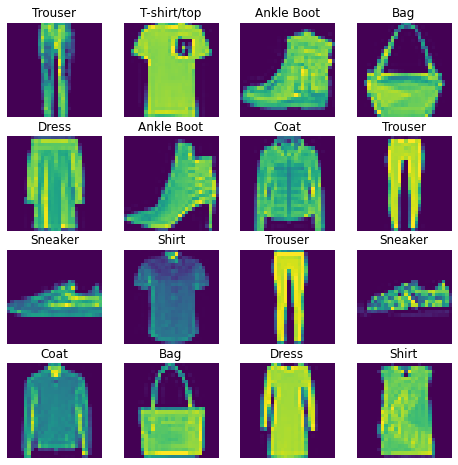

In [7]:
fig, axes = plt.subplots(4, 4, figsize = (8,8))
for row in axes:
    for ax in row:
        index = np.random.randint(60000)
        img = mnist_train.drop('label', axis=1).values[index].reshape(28,28)
        cloths = mnist_train['label'][index]
        ax.imshow(img)
        ax.set_title(labels[cloths])
        ax.set_axis_off()


# Data Formatting

In [8]:
from sklearn.model_selection import train_test_split, cross_val_score

In [9]:
mnist_train.shape, mnist_test.shape

# 6:1 aplit

data = mnist_train[list(mnist_train.columns)[1:]].to_numpy()
label = mnist_train['label'].values

testing =  mnist_test[list(mnist_test.columns)[1:]].to_numpy()

## normalize
data = data / 255



## create train and validation datasets
X_train, X_val, y_train, y_val = train_test_split(data, label, test_size=0.2)

In [10]:
X_train.shape, y_train.shape

((48000, 784), (48000,))

# PCA

In [11]:
import sklearn
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [12]:
PCA = sklearn.decomposition.PCA(n_components=2)
principalComponents = PCA.fit_transform(X_train)
PCDF = pd.DataFrame(principalComponents, columns = ['principal component 1', 'principal component 2'])
PCDF['target'] = y_train

In [13]:
PCDF.head()

,principal component 1,principal component 2,target
0,6.264833,3.996817,2
1,-2.622973,-4.668352,1
2,-2.744275,4.395948,9
3,1.096708,1.880005,8
4,7.621451,1.435906,4


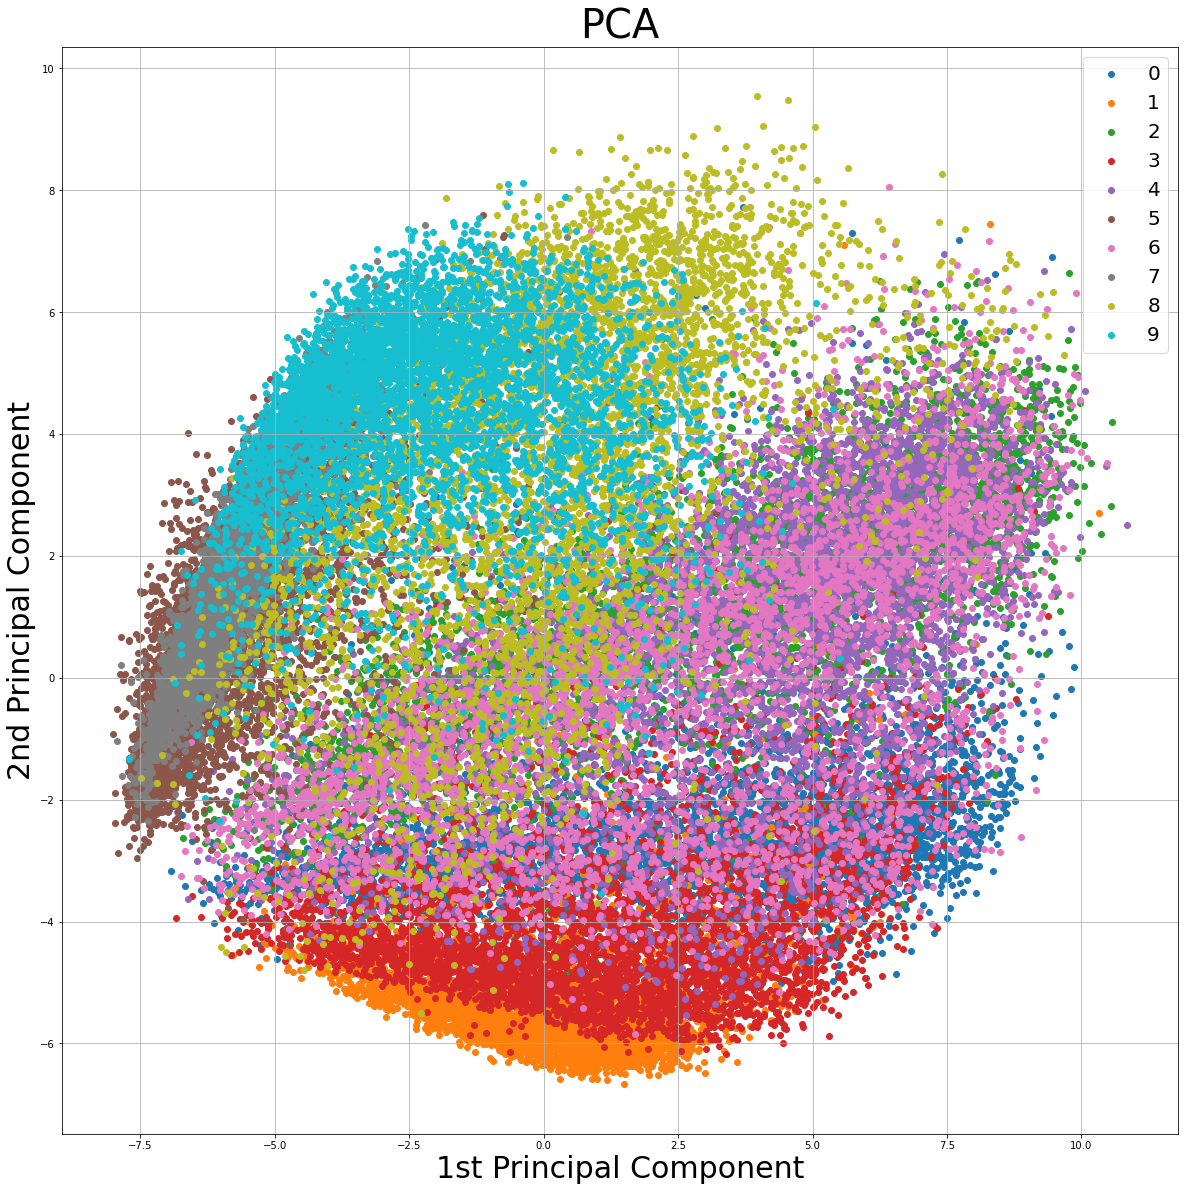

In [14]:
fig = plt.figure(figsize = (20,20))
ax = fig.add_subplot(1,1,1) 
targets = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
colors = ['r', 'g', 'b' ,'c','m','y','k', 'k','k','k']
for target, color in zip(targets, colors):
    correct = PCDF['target'] == target
    ax.scatter(PCDF.loc[correct, 'principal component 1'],
               PCDF.loc[correct, 'principal component 2']
               ,cmap = plt.get_cmap('jet', 10) )

ax.set_xlabel('1st Principal Component', fontsize = 30)
ax.set_ylabel('2nd Principal Component', fontsize = 30)
ax.set_title('PCA', fontsize = 40)
ax.legend(targets, prop={'size': 20})
ax.grid()

# Modeling

In [15]:
import tensorflow as tf

Baseline Model

In [16]:
#train_X = train_X.reshape(( 48000, 28, 28, 1))
data = data.reshape(( 60000, 28, 28, 1))


CallBacks

In [17]:
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('val_accuracy') >= 0.997):
            print("\nReached 99.7% accuracy so cancelling training!")
            self.model.stop_training = True

early = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, mode='max',
                                        restore_best_weights=True)

NN

In [18]:
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense, BatchNormalization, MaxPooling2D
from keras.optimizers import Adam, RMSprop
def NN_model():

    model = Sequential()

    model.add(Flatten())
    model.add(Dense(128, activation = 'relu'))
    model.add(Dense(128, activation = 'relu'))
    model.add(Dense(10, activation = 'softmax'))

    optimizer = Adam(lr=0.001)

    model.compile(optimizer = optimizer,
                  loss = 'sparse_categorical_crossentropy',
                  metrics  = 'accuracy')
    return model


In [19]:
baseline = NN_model()

history = baseline.fit(data, label, epochs=10, batch_size =64,validation_split = 0.2 ,callbacks=[early])


Epoch 1/10
750/750 [==============================] - 3s 3ms/step - loss: 0.6972 - accuracy: 0.7599 - val_loss: 0.4204 - val_accuracy: 0.8518
Epoch 2/10
750/750 [==============================] - 1s 2ms/step - loss: 0.3927 - accuracy: 0.8584 - val_loss: 0.4038 - val_accuracy: 0.8544
Epoch 3/10
750/750 [==============================] - 1s 2ms/step - loss: 0.3502 - accuracy: 0.8724 - val_loss: 0.3556 - val_accuracy: 0.8709
Epoch 4/10
750/750 [==============================] - 1s 2ms/step - loss: 0.3286 - accuracy: 0.8788 - val_loss: 0.3391 - val_accuracy: 0.8793
Epoch 5/10
750/750 [==============================] - 1s 2ms/step - loss: 0.3112 - accuracy: 0.8856 - val_loss: 0.3449 - val_accuracy: 0.8773
Epoch 6/10
750/750 [==============================] - 2s 2ms/step - loss: 0.2905 - accuracy: 0.8930 - val_loss: 0.3234 - val_accuracy: 0.8850
Epoch 7/10
750/750 [==============================] - 2s 3ms/step - loss: 0.2733 - accuracy: 0.8990 - val_loss: 0.3322 - val_accuracy: 0.8858
Epoch 

In [20]:
results = baseline.evaluate(X_val, y_val, batch_size=128)


94/94 [==============================] - 0s 2ms/step - loss: 0.2530 - accuracy: 0.9057


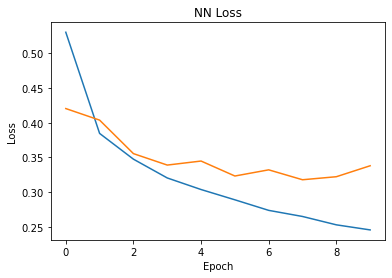

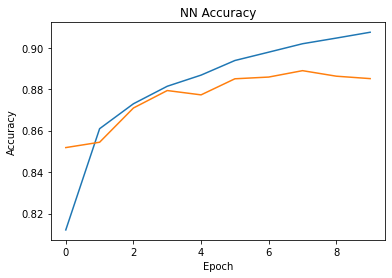

In [21]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('NN Loss')

plt.show()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('NN Accuracy')

plt.show()

In [22]:
'''
def TF_model():
    model = Sequential()
    model.add(keras.applications.inception_resnet_v2.InceptionResNetV2(weights='imagenet',
                                                                      include_top=False,
                                                                      input_shape=(28, 28, 3)))
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(33, activation='softmax'))

    model.compile(optimizer=keras.optimizers.Adam(lr=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
    return  model'''


"\ndef TF_model():\n    model = Sequential()\n    model.add(keras.applications.inception_resnet_v2.InceptionResNetV2(weights='imagenet',\n                                                                      include_top=False,\n                                                                      input_shape=(28, 28, 3)))\n    model.add(Flatten())\n    model.add(Dense(256, activation='relu'))\n    model.add(Dropout(0.5))\n    model.add(Dense(33, activation='softmax'))\n\n    model.compile(optimizer=keras.optimizers.Adam(lr=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])\n    return  model"